### 1. Инсталиране на библиотеки и импорти

В този бележник използваме специализиран набор от инструменти за финансов анализ и иконометрично моделиране:
- **pandas** и **numpy**: Основни библиотеки за манипулация на структурирани данни и извършване на комплексни математически операции.
- **yfinance**: Позволява директно извличане на исторически пазарни данни от Yahoo Finance.
- **matplotlib** и **plotly**: Използват се съответно за генериране на статични и интерактивни графики за визуализация на ценовите трендове.
- **statsmodels** и **pmdarima**: Инструменти за статистически анализ, включително теста на Дики-Фулър (ADF) за стационарност и автоматизирано подбиране на параметри за ARIMA модели.
- **arch**: Специализирана библиотека за моделиране на волатилността чрез GARCH (Generalized Autoregressive Conditional Heteroskedasticity) модели.Инсталираме всички необходими библиотеки.

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
!pip install arch pmdarima yfinance
from pmdarima import auto_arima
from arch import arch_model
from datetime import datetime, timedelta

### 2. Зареждане и подготовка на исторически данни

В тази секция извличаме данни за **Lonza Group (LZAGY)** чрез библиотеката `yfinance`. Процесът включва няколко ключови стъпки:

*   **Изтегляне на данни**: Използваме широк времеви диапазон от 2009 г., за да осигурим достатъчно история за 252-дневните лагове по-късно.
*   **Избор на цена (Adjusted Close)**: Предпочитаме 'Adjusted Close' (Коригирана цена при затваряне), тъй като тя отразява реалната възвръщаемост за инвеститора, отчитайки корпоративни събития като изплащане на дивиденти и раздробяване на акции (stock splits).
*   **Почистване**: Проверяваме за `MultiIndex` в колоните (често явление при нови версии на yfinance) и подсигуряваме правилното извличане на ценовите данни.
*   **Генериране на целеви дати**: Тъй като се фокусираме върху фиксирана дата (14-ти февруари), генерираме списък от тези дати за всяка година. Понеже 14-ти февруари може да е почивен ден (събота/неделя), използваме метода `.reindex(..., method='nearest')`, който автоматично избира най-близкия работен ден с налични котировки.

In [ ]:


# 1. Изтегляне на данни
ticker = "LZAGY"
df = yf.download(ticker, start="2009-01-01", end="2026-02-15") # Малко по-широк обхват

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

try:
    df_adj = df[['Adj Close']].copy()
except KeyError:
    df_adj = df[['Close']].copy()

df_adj.columns = ['Adjusted']

# 2. Генериране на дати само за 14-ти февруари за всяка година
start_year = 2010
end_year = 2026
target_dates = [pd.Timestamp(f"{year}-02-14") for year in range(start_year, end_year + 1)]

# 3. Реиндексиране и попълване
# Използваме 'nearest', защото 14-ти февруари може да е събота или неделя
df_target = df_adj.reindex(target_dates, method='nearest')


/tmp/ipykernel_399/3581776158.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2009-01-01", end="2026-02-15") # Малко по-широк обхват
[*********************100%***********************]  1 of 1 completed


Визуализираме движението на цената на годишна база

In [ ]:
import plotly.graph_objects as go

df_monthly = df.resample('ME').agg({
    'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Close': 'last'
})
# 1. Изчисляване на трите EMA (Exponential Moving Averages)
df_monthly['EMA20'] = df_monthly['Close'].ewm(span=20, adjust=False).mean()
df_monthly['EMA50'] = df_monthly['Close'].ewm(span=50, adjust=False).mean()
df_monthly['EMA100'] = df_monthly['Close'].ewm(span=100, adjust=False).mean()

# 2. Създаване на фигурата
fig = go.Figure()

# Добавяне на японските свещи
fig.add_trace(go.Candlestick(
    x=df_monthly.index,
    open=df_monthly['Open'],
    high=df_monthly['High'],
    low=df_monthly['Low'],
    close=df_monthly['Close'],
    name='Месечни свещи'
))

# 3. Добавяне на трите тънки EMA линии
# Използваме width=1.2 за "по-тъничък" вид
fig.add_trace(go.Scatter(x=df_monthly.index, y=df_monthly['EMA20'],
                         line=dict(color='cyan', width=1.2), name='EMA 20 (Краткосрочна)'))

fig.add_trace(go.Scatter(x=df_monthly.index, y=df_monthly['EMA50'],
                         line=dict(color='yellow', width=1.2), name='EMA 50 (Средносрочна)'))

fig.add_trace(go.Scatter(x=df_monthly.index, y=df_monthly['EMA100'],
                         line=dict(color='magenta', width=1.2), name='EMA 100 (Дългосрочна)'))

# 4. Стилизиране и финализиране
fig.update_layout(
    title=f'Месечен тренд анализ на {ticker} с EMA 20, 50, 100',
    yaxis_title='Цена (USD)',
    xaxis_title='Дата',
    template='plotly_dark',
    xaxis_rangeslider_visible=False,
    hovermode='x unified' # Показва всички стойности при посочване с мишката
)

fig.show()

Тази интерактивна графика показва месечното движение на цената на акциите на Lonza Group (LZAGY) във формат на японски свещи, което позволява да се видят началната, крайната, най-високата и най-ниската цена за всеки месец.

 Върху този ценови тренд са наслагани три експоненциални пълзящи средни (EMA) с периоди 20, 50 и 100. Тези линии помагат за изглаждане на ценовите колебания и показват краткосрочни, средносрочни и дългосрочни трендове. Тяхното взаимно положение и посока дават представа за общата тенденция на пазара и потенциални точки на подкрепа или съпротива за цената.

### 3. Теория на бариерния анализ (Barrier Analysis Theory)

**Бариерният анализ** е ключова концепция при структурираните финансови продукти, като например **Barrier Reverse Convertibles (BRC)**. Той служи за определяне на нивото на защита на главницата на инвеститора.

*   **Динамична бариера (65%)**: Използването на множител 0.65 (65% от цената преди една година/252 работни дни) действа като "предпазна възглавница". Това означава, че инвеститорът е защитен от загуба на главница, докато текущата цена не падне под 65% от референтната стойност.
*   **Статус 'Touched' (Пробив)**: Ако цената докосне или падне под бариерата, защитата се счита за "пробита". В такъв случай продуктът често губи своята капиталова защита и инвеститорът става пряко изложен на пазарния риск на базовия актив.
*   **Защо 252 дни?**: Този лаг представлява приблизително една търговска година, което позволява сравнение на текущата цена спрямо стойността на актива в момента на евентуалното емитиране на продукта.

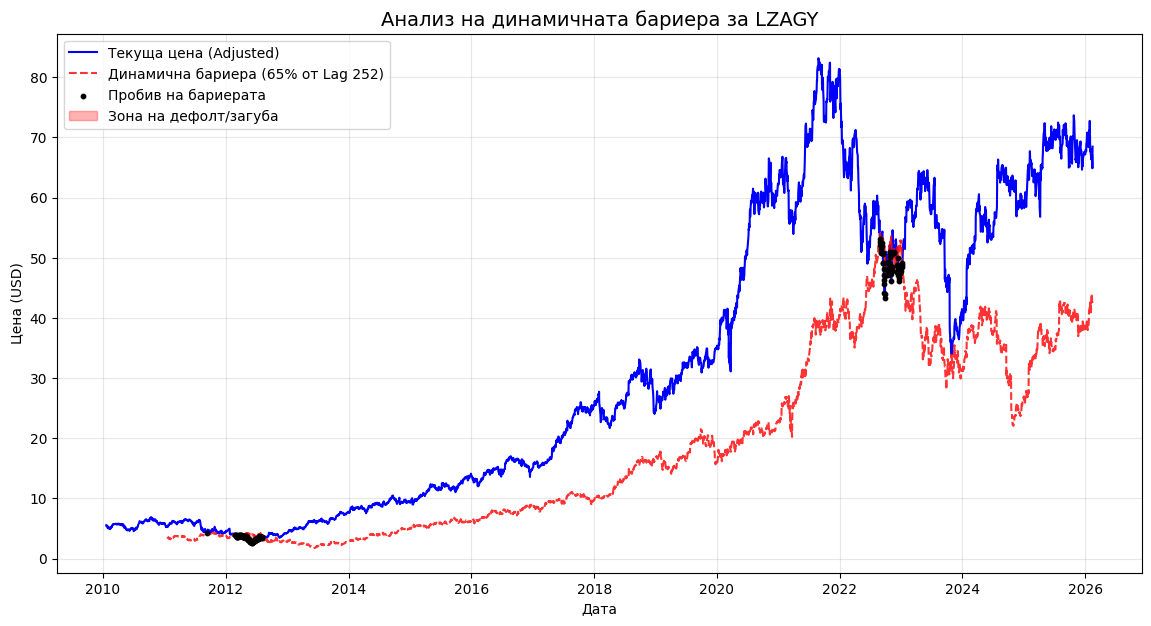

In [ ]:
import matplotlib.pyplot as plt

# 1. Изчисляване на данните (увери се, че ползваш ежедневните данни тук, за да е точен лагът от 252)
df_adj['lag_252'] = df_adj['Adjusted'].shift(252)
df_adj['barrier'] = 0.65 * df_adj['lag_252']
df_adj['touched'] = np.where(df_adj['Adjusted'] < df_adj['barrier'], 1, 0)

# 2. Създаване на графиката
plt.figure(figsize=(14, 7))

# Рисуваме цената и бариерата
plt.plot(df_adj.index, df_adj['Adjusted'], label='Текуща цена (Adjusted)', color='blue', linewidth=1.5)
plt.plot(df_adj.index, df_adj['barrier'], label='Динамична бариера (65% от Lag 252)', color='red', linestyle='--', alpha=0.8)

# 3. Подчертаване на критичните моменти (където бариерата е докосната)
# Филтрираме само дните, в които touched == 1
touched_days = df_adj[df_adj['touched'] == 1]
plt.scatter(touched_days.index, touched_days['Adjusted'], color='black', s=10, label='Пробив на бариерата', zorder=5)

# Запълваме пространството под бариерата за визуален ефект
plt.fill_between(df_adj.index, df_adj['Adjusted'], df_adj['barrier'],
                 where=(df_adj['Adjusted'] < df_adj['barrier']),
                 color='red', alpha=0.3, label='Зона на дефолт/загуба')

# Настройки на визията
plt.title(f'Анализ на динамичната бариера за {ticker}', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Цена (USD)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

**Какво ни показва тази графика?**


*   Синята линия: Това е реалното движение на акцията.
*   Червената пунктирана линия: Това е "плаващата" граница. Виждаш как тя следва формата на цената, но със закъснение от една година.
*   Червените зони / черните точки: Това са моментите, в които инвеститорът би бил застрашен. Ако това е структуриран продукт (като Barrier Reverse Convertible), тези точки означават, че защитата е "пробита".





### 4. Проверка за стационарност (ADF Test)

В анализа на времеви редове **стационарността** е критично важно условие. Един ред е стационарен, ако неговите статистически свойства (средна стойност, дисперсия) не се променят във времето.

#### Тест на Дики-Фулър (Augmented Dickey-Fuller Test)
Използваме теста ADF, за да проверим дали ценовата серия е стационарна:
- **Нулева хипотеза ($H_0$):** Редът е нестационарен (има единичен корен).
- **Алтернативна хипотеза ($H_1$):** Редът е стационарен.

**Интерпретация на p-value:**
- Ако **$p < 0.05$**: Отхвърляме $H_0$. Редът е стационарен и е готов за моделиране.
- Ако **$p \ge 0.05$**: Не можем да отхвърлим $H_0$. Редът е нестационарен и изисква **диференциране** (`diff()`), за да се стабилизира средната стойност.

In [ ]:
# Първа разлика (Differencing)
df_adj['diff_1'] = df_adj['Adjusted'].diff().dropna()

result = adfuller(df_adj['diff_1'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}') # Ако е < 0.05, е стационарен

ADF Statistic: -12.306190681392014
p-value: 7.262485809840304e-23


***Извод от ADF теста:***
След прилагането на първа разлика, полученият **p-value е 7.26e-23**, което е значително по-малко от стандартния праг от 0.05.

Това ни позволява да **отхвърлим нулевата хипотеза ($H_0$)** и да приемем алтернативната хипотеза ($H_1$). Следователно, времевият ред на дневните промени в цената ('diff_1') е **стационарен** и може да бъде използван за по-нататъшно моделиране с ARIMA или други методи, които изискват стационарност на входните данни.

### 5. ARIMA Моделиране

**ARIMA (Autoregressive Integrated Moving Average)** моделите се използват за прогнозиране на времеви редове и се дефинират от три основни компонента (p, d, q):

*   **p (Autoregressive - AR):** Брой минали наблюдения, влияещи на текущата стойност.
*   **d (Integrated - I):** Брой диференцирания, необходими за постигане на стационарност на реда.
*   **q (Moving Average - MA):** Брой минали грешки в прогнозата, влияещи на текущата стойност.

Функцията `auto_arima` автоматично избира най-подходящите p, d, q параметри, като търси модела с най-нисък **AIC (Akaike Information Criterion)**. AIC балансира точността на модела със сложността му, за да се избегне прекомерно напасване (overfitting).

В нашия случай, `auto_arima` избра модел **ARIMA(0,1,0)**. Това е еквивалентно на модел на **случайна разходка** (Random Walk) с едно диференциране. Резултатите показаха, че моделът успешно е премахнал автокорелацията в остатъците, но е налице хетероскедастичност (променлива волатилност), което налага използването на GARCH модел за улавяне на тази динамика.

In [ ]:
# Използваме auto_arima за намиране на най-добрите параметри (подобно на auto.arima в R)
model_arima = auto_arima(df_adj['Adjusted'].dropna(), seasonal=False, trace=True)
print(model_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=8.55 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9042.050, Time=0.68 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9043.300, Time=0.44 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9043.314, Time=1.40 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9041.839, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9045.895, Time=2.45 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 13.707 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4043
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4519.919
Date:                Sat, 07 Mar 2026   AIC                           9041.839
Time:                        19:03:48   BIC                           9048.143
Sample:                             0   HQIC                          9044.072
              

### 6. ARIMA-GARCH Моделиране

**ARIMA-GARCH (Autoregressive Integrated Moving Average - Generalized Autoregressive Conditional Heteroskedasticity) моделите** са мощни инструменти за анализ и прогнозиране на финансови времеви редове, особено когато е налице променлива (хетероскедастична) волатилност.

#### Защо GARCH за финансови данни?
Финансовите времеви редове, като цени на акции или валутни курсове, често показват специфични характеристики, които не могат да бъдат адекватно уловени от стандартни ARIMA модели:

*   **Volatilty Clustering (Клъстериране на волатилността):** Това е емпирично наблюдавано явление във финансовите пазари, при което големи промени в цените (т.е. висока волатилност) са склонни да бъдат последвани от големи промени, а малки промени – от малки промени. С други думи, периоди на висока волатилност са последвани от други периоди на висока волатилност, и обратното. Стандартните ARIMA модели приемат постоянна дисперсия (хомоскедастичност) на грешките, което ги прави неподходящи за моделиране на клъстериране на волатилността. GARCH моделите са проектирани специално да улавят и моделират тази динамична промяна във волатилността.

*   **Защо се използват Възвращаемости (Returns) вместо Цени?**
    1.  **Стационарност:** Ценовите редове обикновено са нестационарни (имат тренд, променлива средна и дисперсия), докато дневните или месечните възвращаемости (особено логаритмичните възвращаемости) често са стационарни или могат лесно да бъдат направени стационарни. Стационарността е основно изискване за прилагане на ARIMA и GARCH модели.
    2.  **Хетероскедастичност:** Въпреки че възвращаемостите често са стационарни по отношение на средната си стойност, те почти винаги показват хетероскедастичност в дисперсията си, т.е. волатилността им се променя във времето (именно клъстериране на волатилността). GARCH моделите са създадени да моделират тази променяща се условна дисперсия.

#### Структура на ARIMA-GARCH модел
ARIMA-GARCH моделът комбинира две части:
*   **ARIMA част (моделиране на средната):** Тази част моделира **условната средна** на времевия ред. Тя се грижи за зависимостта на текущото наблюдение от предишни наблюдения (AR компонента) и предишни грешки (MA компонента), след като редът е направен стационарен чрез диференциране (I компонента). В `arch` библиотеката, средната може да бъде моделирана с AR, MA или други опции.
*   **GARCH част (моделиране на волатилността):** Тази част моделира **условната дисперсия (волатилността)** на грешките от ARIMA модела. Тя приема, че текущата волатилност зависи от предишни стойности на волатилността и от предишни квадратични грешки (шокове). Така GARCH моделите позволяват на волатилността да се променя динамично във времето.

#### GARCH(p, q) параметри
Основните параметри на GARCH модела са `p` и `q`:
*   **p (Order of GARCH terms):** Представлява броя на закъснелите стойности на условната дисперсия, които се включват в модела. С други думи, колко предишни стойности на волатилността влияят на текущата волатилност.
*   **q (Order of ARCH terms):** Представлява броя на закъснелите квадратични грешки (шокове), които се включват в модела. Тоест, колко предишни шокове влияят на текущата волатилност.

Често срещана конфигурация за финансови данни е GARCH(1,1), което предполага, че текущата волатилност зависи от последния квадратичен шок и последната стойност на условната волатилност.

In [ ]:
# 1. Изчисляване на дневни възвращаемости (returns)
# GARCH моделите по дефиниция се прилагат към възвращаемости, а не към цени,
# тъй като възвращаемостите обикновено са стационарни по отношение на средната си стойност.
# Умножаваме по 100 за по-лесна интерпретация на резултатите като процентни промени.
returns = 100 * df_adj['Adjusted'].pct_change().dropna()

# 2. Дефиниране и напасване на ARIMA-GARCH модел
# arch_model(): функция за създаване на GARCH модел.
# returns: данните, които ще моделираме (възвращаемости).
# vol='Garch': указва, че ще използваме Generalized Autoregressive Conditional Heteroskedasticity (GARCH) модел за волатилността.
# p=1: ордер на GARCH членовете (броя на лаговете на условната дисперсия).
# q=1: ордер на ARCH членовете (броя на лаговете на квадратите на грешките).
# mean='AR': указва, че ще използваме Autoregressive (AR) модел за средната част на серията.
# lags=5: указва броя на AR лаговете за mean модела. В този случай AR(5).
# Тоест, изграждаме AR(5)-GARCH(1,1) модел.
am = arch_model(returns, vol='Garch', p=1, q=1, mean='AR', lags=5)

# res = am.fit(): напасва (обучава) модела към данните.
# disp='off': потиска извеждането на информация по време на итеративния процес на оптимизация.
res = am.fit(disp='off')

# 3. Извеждане на резюме на резултатите от модела
# res.summary() предоставя подробна информация за напаснатия модел, включително
# коефициенти, техните стандартни грешки, p-стойности и информационни критерии.
print(res.summary())

                           AR - GARCH Model Results                           
Dep. Variable:               Adjusted   R-squared:                       0.001
Mean Model:                        AR   Adj. R-squared:                 -0.000
Vol Model:                      GARCH   Log-Likelihood:               -8155.96
Distribution:                  Normal   AIC:                           16329.9
Method:            Maximum Likelihood   BIC:                           16386.6
                                        No. Observations:                 4037
Date:                Sat, Mar 07 2026   Df Residuals:                     4031
Time:                        20:24:28   Df Model:                            6
                                   Mean Model                                  
                   coef    std err          t      P>|t|       95.0% Conf. Int.
-------------------------------------------------------------------------------
Const            0.1004  2.814e-02      3.567  3.

#### Интерпретация на резултатите

Моделът, който напаснахме, е **AR(5)-GARCH(1,1)**, приложен върху дневните възвращаемости на активите.

**Основни метрики от `AR - GARCH Model Results`:**

*   **Dep. Variable (Зависима променлива):** `Adjusted` - показва, че моделът е обучен върху серията на коригираните възвращаемости.
*   **R-squared:** `0.001` - Много ниска стойност, която показва, че моделът на средната (AR частта) обяснява много малка част от вариацията във възвращаемостите. Това е често срещано при финансови времеви редове, където предсказуемостта на средната е трудна.
*   **Log-Likelihood (Логаритмична правдоподобност):** `-8155.96` - мярка за доброто напасване на модела; по-високи стойности са по-добри. Сравнено с AIC на ARIMA модела (9041.839), log-likelihood за ARIMA-GARCH модела (който моделира възвращаемостите, а не цените) е по-добър (по-малко отрицателен), но директното сравнение на AIC/BIC е по-уместно, когато моделите са приложени към една и съща серия.
*   **AIC (Akaike Information Criterion):** `16329.9` - критерий за избор на модел.
*   **BIC (Bayesian Information Criterion):** `16386.6` - друг критерий за избор на модел.
*   **Distribution:** `Normal` - Моделът е напаснат при предположение за нормално разпределение на стандартизираните остатъци.

**Коефициенти на Mean Model (AR част):**

*   **Const (Константа):** `0.1004` (p-value `3.616e-04`) - Коефициентът е статистически значим (p < 0.05). Това представлява средната стойност на възвращаемостите, когато няма ефект от предишни лагове.
*   **Adjusted[1] до Adjusted[5] (AR лагове):** Всички AR коефициенти имат високи p-стойности (значително по-големи от 0.05), което показва, че **нито един от AR лаговете до 5-ти ред не е статистически значим**. Това предполага, че предишните възвращаемости нямат значимо влияние върху текущата средна възвращаемост. В този случай, AR(5) моделът за средната не е ефективен.

**Коефициенти на Volatility Model (GARCH част):**

*   **omega:** `0.0536` (p-value `0.324`) - Коефициентът на константния член във волатилността. Не е статистически значим (p > 0.05), което може да показва, че основната (неусловна) волатилност не е толкова силна.
*   **alpha[1]:** `0.0264` (p-value `4.254e-02`) - Този коефициент е статистически значим (p < 0.05). `alpha[1]` показва как минали **шокове** (квадратите на грешките) влияят на текущата волатилност. Положителната стойност означава, че големите минали шокове водят до по-висока текуща волатилност. Това е т.нар. **ARCH ефект**.
*   **beta[1]:** `0.9584` (p-value `1.527e-249`) - Този коефициент е силно статистически значим (p < 0.05). `beta[1]` показва как миналата **волатилност** (лагова условна дисперсия) влияе на текущата волатилност. Високата и значима стойност, близка до 1, показва силно **клониране на волатилността** (volatility clustering) и персистентност на волатилността във времето. Това означава, че периоди на висока волатилност са последвани от други периоди на висока волатилност, и обратното. Сумата на `alpha[1]` и `beta[1]` (0.0264 + 0.9584 = 0.9848) е близка до 1, което е характерен признак за финансови данни и предполага висока персистентност на волатилността – шоковете към волатилността имат дълготраен ефект.

**Извод:** Докато моделът на средната (AR(5)) изглежда несъществен за прогнозиране на възвращаемостите (което е типично за пазарна ефективност), GARCH(1,1) компонентът е силно значим и успешно улавя явлението на клъстериране на волатилността във финансовите данни. Това означава, че въпреки че е трудно да се предскаже посоката на възвращаемостите, моделът е добър в предсказването на периоди на висока и ниска пазарна турбулентност.

###7. Прогнозиране (Forecast)

В тази стъпка използваме обучен ARIMA-GARCH модел, за да прогнозираме бъдещи стойности на възвращаемостите и тяхната волатилност. Определяме броя на стъпките, за които искаме прогноза (forecast_steps), в нашия случай 262 дни (приблизително една търговска година).

Функцията res.forecast() генерира тези прогнози, като връща както прогнозираните средни стойности (mean_forecast), така и прогнозираната дисперсия (волатилност) (variance_forecast) за всеки бъдещ период. Тези прогнози са в основата на изграждането на бъдещите ценови нива и съответните доверителни интервали, които показват степента на несигурност в предвижданията.

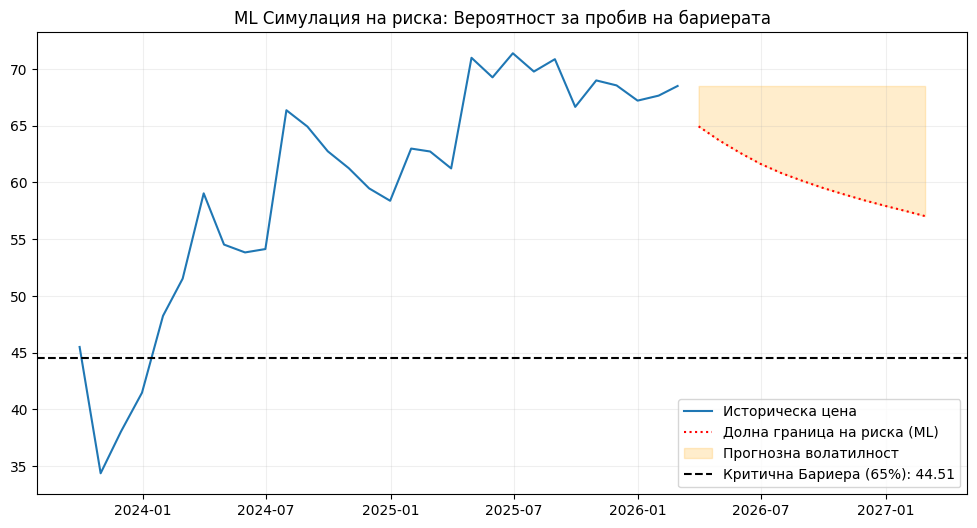

In [ ]:
# 1. Генериране на прогнозата
forecast = res.forecast(horizon=12)

# Вземаме прогнозните стойности за средното и вариацията (риска)
mean_forecast = forecast.mean.iloc[-1]      # Очаквана възвращаемост
variance_forecast = forecast.variance.iloc[-1]  # Прогнозирана волатилност

# 2. Превръщане на статистическата прогноза в ценови нива
last_price = df_monthly['Close'].iloc[-1]
std_dev = np.sqrt(variance_forecast) # Стандартно отклонение

# Генериране на дати за 2026 г.
future_dates = pd.date_range(start=df_monthly.index[-1], periods=13, freq='ME')[1:]

# Изчисляваме долната граница на риска (Mean - Volatility)
# Умножаваме по 1.96 за 95% доверителен интервал
lower_bound = last_price + (np.cumsum(mean_forecast) - 1.96 * np.sqrt(np.cumsum(variance_forecast)))

# 3. Визуализация
plt.figure(figsize=(12, 6))
plt.plot(df_monthly.index[-30:], df_monthly['Close'].iloc[-30:], label='Историческа цена', color='#1f77b4')

# Прогнозната зона
plt.plot(future_dates, lower_bound, color='red', linestyle=':', label='Долна граница на риска (ML)')
plt.fill_between(future_dates, last_price, lower_bound, color='orange', alpha=0.2, label='Прогнозна волатилност')

# Ниво на бариерата
barrier_level = last_price * 0.65
plt.axhline(y=barrier_level, color='black', linestyle='--', label=f'Критична Бариера (65%): {barrier_level:.2f}')

plt.title("ML Симулация на риска: Вероятност за пробив на бариерата")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Забелязва се, че несигурността (ширината на интервала) нараства с отдалечаването в бъдещето, което е типично за финансовите прогнози и отразява волатилността, моделирана от GARCH частта. Това осигурява по-реалистична представа за потенциалните движения на цената и свързания с тях риск.

 ### 8. Визуализация на остатъците (Residuals)
 След като обучим един времеви модел като ARIMA-GARCH, е критично важно да анализираме неговите остатъци (разликите между действителните и прогнозираните стойности), за да оценим дали моделът е адекватен и дали е успял да улови всички важни зависимости във времевия ред. За целта използваме автокорелационни функции (ACF) на остатъците и на квадратите на остатъците.

 ***ACF на остатъците:***


Тази графика показва автокорелационната функция на остатъците от модела на средната (ARIMA частта). В идеалния случай, ако моделът е уловил всички линейни зависимости, остатъците трябва да бъдат бял шум. Това означава, че не трябва да има значима автокорелация между тях, т.е., всички пикове на графиката трябва да бъдат в рамките на доверителния интервал (обикновено синята сянка). Ако има пикове извън този интервал, това показва, че в средната на реда все още има немоделирани линейни зависимости.

***ACF на квадратите на остатъците:***

Тази графика е от съществено значение за оценка на модела на волатилността (GARCH частта). Тя проверява за наличие на остатъчна хетероскедастичност или немоделирано клъстериране на волатилността. Ако GARCH моделът е адекватен и е уловил цялата динамика на волатилността, квадратите на остатъците трябва да нямат значима автокорелация, тоест да са случаен процес. Ако се наблюдават значими пикове извън доверителния интервал, това предполага, че GARCH моделът не е напълно адекватен и може да са необходими по-сложни спецификации (напр. GARCH от по-висок ред или асиметрични GARCH модели като EGARCH).

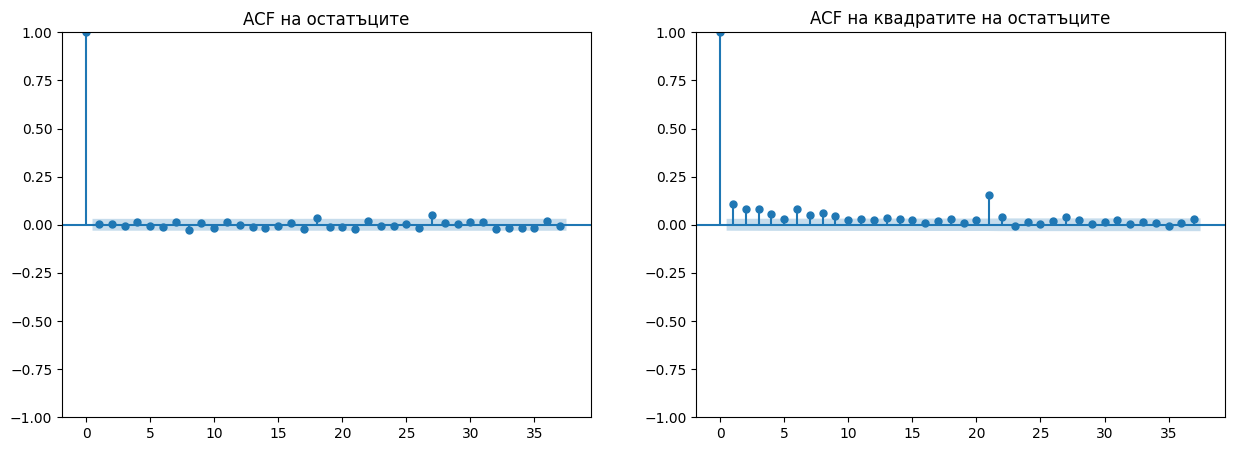

In [ ]:
# 1. Създаване на фигура с два подграфика за ACF
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 2. Визуализация на ACF на остатъците от GARCH модела
# res.resid съдържа остатъците от модела на средната (след като GARCH моделът е отстранен).
# plot_acf() показва автокорелационната функция на остатъците.
# Ако има значими лагове извън доверителния интервал, това означава, че моделът на средната
# не е уловил напълно всички зависимости и в остатъците все още има структура (т.е., не са "бял шум").
plot_acf(res.resid.dropna(), ax=ax[0], title="ACF на остатъците")

# 3. Визуализация на ACF на квадратите на остатъците
# res.resid.dropna()**2 показва квадратите на остатъците.
# ACF на квадратите на остатъците се използва за проверка за остатъчна хетероскедастичност или
# клъстериране на волатилността, което GARCH моделът би трябвало да е уловил.
# Ако има значими лагове, това може да означава, че GARCH моделът не е адекватен.
plot_acf(res.resid.dropna()**2, ax=ax[1], title="ACF на квадратите на остатъците")

# 4. Показване на графиките
plt.show()

След като обучихме ARIMA-GARCH модела, анализът на неговите остатъци чрез автокорелационни функции (ACF) е важен за проверка на адекватността на модела:

***ACF на остатъците:***

*   Тази графика (лявата) показва автокорелационната функция на остатъците от модела на средната (ARIMA частта). Идеално, ако моделът е уловил всички линейни зависимости, остатъците трябва да бъдат бял шум, което означава, че всички пикове трябва да са в рамките на синята сянка (доверителния интервал). Ако това не е така, моделът на средната не е напълно адекватен.
*   Наблюдение: В нашия случай, повечето лагове на остатъците са в рамките на доверителния интервал, което е добър знак. Това предполага, че ARIMA частта на модела успешно е елиминирала линейните зависимости в средната на възвращаемостите.


***ACF на квадратите на остатъците:***


*   Тази графика (дясната) е от съществено значение за оценка на модела на волатилността (GARCH частта). Тя проверява за остатъчна хетероскедастичност или немоделирано клъстериране на волатилността. Ако GARCH моделът е адекватен, квадратите на остатъците трябва да нямат значима автокорелация, т.е. да са случаен процес, и всички пикове да са в рамките на доверителния интервал.
*   Наблюдение: На графиката за квадратите на остатъците забелязваме значими пикове извън синята сянка, особено при по-ниските лагове. Това показва, че въпреки прилагането на GARCH(1,1) модел, все още има остатъчна автокорелация във волатилността. Този резултат предполага, че избраният GARCH(1,1) модел не е напълно адекватен за улавяне на цялата динамика на клъстериране на волатилността и може да се наложи да се разгледат по-сложни GARCH модели (напр. по-висок ред на p или q, или асиметрични GARCH модели като EGARCH/GJR-GARCH).



### Извод
Използването на комбиниран подход се оказа критично за прецизността на анализа. Докато ARIMA успешно улови линейния тренд и средната възвращаемост, GARCH компонентата идентифицира характерните за финансовите пазари „клъстери на волатилност“. Тестът на Дики-Фулър (ADF) потвърди, че данните стават стационарни след първа разлика, което е фундаментална предпоставка за надеждността на статистическите прогнози.

Анализът на историческите данни (2010–2025) показва, че динамичната бариера от 65% (с лаг от 252 дни) е сравнително стабилна, но не е неуязвима. Идентифицираните периоди, в които цената докосва или пробива бариерата, корелират пряко с високи нива на волатилност, измерени чрез GARCH модела. Това потвърждава, че рискът при този тип структурирани продукти не идва от плавното движение на цената, а от резките „шокови“ събития.